# Challenge 9 — Análisis de Actividad de Producto

## 0. Configuración Inicial

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('docs/product_activity.csv')

# Guardar conteo original antes de cualquier limpieza
RAW_COUNT = len(df)
print(f"Dataset cargado: {RAW_COUNT} filas, {df.shape[1]} columnas")

Dataset cargado: 8782 filas, 12 columnas


## 1. Exploración Inicial
Medir antes de limpiar: entender la estructura, detectar nulos,
duplicados y valores sucios en las columnas categóricas.

### 1.1 — Vista general del dataset

In [2]:
# Primeras filas, tipos de dato y estadísticas numéricas
print("=== head() ===")
display(df.head())

print("\n=== info() ===")
display(df.info())

print("\n=== describe() ===")
display(df.describe().round(2))

=== head() ===


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile



=== info() ===
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


None


=== describe() ===


,user_age,votes_received,user_total_posts,days_since_signup
count,8028.00,8782.00,8782.00,8782.00
mean,27.90,6.92,8.32,29.48
std,7.55,5.13,6.75,36.82
min,16.00,0.00,1.00,0.00
25%,22.00,3.00,4.00,5.00
50%,28.00,6.00,6.00,17.00
75%,33.00,9.00,11.00,40.00
max,58.00,74.00,39.00,404.00


### 1.2 — Nulos y duplicados exactos

In [3]:
# Nulos por columna
print("Nulos por columna:")
display(df.isnull().sum())

# Duplicados exactos
dup_count = df.duplicated().sum()
print(f"\nFilas duplicadas exactas: {dup_count}")

Nulos por columna:


user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64


Filas duplicadas exactas: 172


### 1.3 — Valores únicos y frecuencias
Detectar variantes sucias (typos, mayúsculas, espacios, valores fuera de diccionario).

In [4]:
# Revisamos las 3 columnas categóricas clave
for col in ["plan_type", "post_category", "device_type"]:
    print(f"\n{col}:")
    display(df[col].value_counts())


plan_type:


plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64


post_category:


post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science          34
 gaming          33
SCIENCE          33
finanse          32
FINANCE          31
EDUCATION        31
educatoin        31
Music            28
healt            28
 health          26
Education        25
GAMING           22
 education       21
Health           21
MUSIC            21
lfe              21
 music           20
Travel           20
TRAVEL           19
HEALTH           18
 travel          16
trvael           16
musc  


device_type:


device_type
web        4416
mobile     3761
desktop     602
tablet        1
console       1
phone         1
Name: count, dtype: int64

### 1.4 — Chequeos lógicos
¿Hay posts creados antes del signup? ¿`days_since_signup` es consistente?

In [5]:
# Convertir fechas temporalmente para los chequeos
signup_tmp = pd.to_datetime(df["created_at"], errors="coerce")
post_tmp = pd.to_datetime(df["post_created_at"], errors="coerce")

# Posts que ocurren ANTES del signup
before_signup = (post_tmp < signup_tmp).sum()
print(f"Posts antes del signup: {before_signup}")

# Mismatches en days_since_signup vs cálculo real
mismatch_pre = ((post_tmp - signup_tmp).dt.days != df["days_since_signup"]).sum()
print(f"Mismatches en days_since_signup: {mismatch_pre}")

Posts antes del signup: 100
Mismatches en days_since_signup: 4479


## 2. Limpieza Básica con Criterio
Eliminar duplicados, normalizar categóricas, convertir fechas,
recalcular `days_since_signup` y separar filas con errores duros.

### 2.1 — Eliminar duplicados exactos

In [6]:
df = df.drop_duplicates()
print(f"Filas después de eliminar {dup_count} duplicados: {len(df)}")

Filas después de eliminar 172 duplicados: 8610


### 2.2 — Normalización canónica
Mapear variantes a los valores canónicos definidos en el challenge.

In [7]:
# Paso 1: minúsculas y sin espacios en blanco
for col in ["plan_type", "device_type", "post_category"]:
    df[col] = df[col].str.strip().str.lower()

# Paso 2: corregir typos conocidos en post_category
CATEGORY_MAP = {
    "sport": "sports", "sporst": "sports", "sp0rts": "sports",
    "tehc": "tech",
    "lfe": "life",
    "gamming": "gaming",
    "musc": "music",
    "educatoin": "education",
    "healt": "health",
    "sciense": "science",
    "trvael": "travel",
    "finanse": "finance",
}
df["post_category"] = df["post_category"].replace(CATEGORY_MAP)

# Verificar resultado
for col in ["plan_type", "device_type", "post_category"]:
    print(f"\n{col} después de normalizar:")
    display(df[col].value_counts())


plan_type después de normalizar:


plan_type
free           6637
pro            1631
enterprise      339
premium           1
vip               1
enterprise+       1
Name: count, dtype: int64


device_type después de normalizar:


device_type
web        4328
mobile     3688
desktop     591
tablet        1
console       1
phone         1
Name: count, dtype: int64


post_category después de normalizar:


post_category
tech         1397
life         1039
sports       1028
science       882
finance       865
gaming        844
education     687
music         685
health        681
travel        500
politics        1
mistery         1
Name: count, dtype: int64

### 2.3 — Conversión de fechas y recálculo de `days_since_signup`

In [8]:
# Convertir a datetime
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["post_created_at"] = pd.to_datetime(df["post_created_at"], errors="coerce")

# Reportar fechas no parseables
print(f"Fechas no parseables - signup: {df['created_at'].isna().sum()}")
print(f"Fechas no parseables - post:   {df['post_created_at'].isna().sum()}")

# Recálculo obligatorio
df["days_since_signup_calc"] = (df["post_created_at"] - df["created_at"]).dt.days

# Comparar con la columna original
mismatch_count = (df["days_since_signup"] != df["days_since_signup_calc"]).sum()
print(f"\nMismatches en days_since_signup: {mismatch_count}")

Fechas no parseables - signup: 1
Fechas no parseables - post:   1

Mismatches en days_since_signup: 4401


### 2.4 — Quarantine (Cuarentena)
Separar filas con errores duros en un DataFrame aparte con `reason_code`.

In [9]:
# Diccionarios válidos según el challenge
VALID_PLANS = {"free", "pro", "enterprise"}
VALID_DEVICES = {"web", "mobile", "desktop"}
VALID_CATEGORIES = {"tech", "life", "sports", "science", "finance",
                    "gaming", "music", "health", "education", "travel"}

# Condiciones de error "duro" con su etiqueta
conditions = {
    "post_before_signup": df["post_created_at"] < df["created_at"],
    "unparseable_date":   df["created_at"].isna() | df["post_created_at"].isna(),
    "invalid_plan":       ~df["plan_type"].isin(VALID_PLANS),
    "invalid_device":     ~df["device_type"].isin(VALID_DEVICES),
    "invalid_category":   ~df["post_category"].isin(VALID_CATEGORIES),
}

# Construir reason_code concatenando motivos
df["reason_code"] = ""
for reason, mask in conditions.items():
    df.loc[mask, "reason_code"] += reason + ";"

# Separar cuarentena vs core
is_quarantine = df["reason_code"] != ""
df_quarantine = df[is_quarantine].copy()
df_clean = df[~is_quarantine].drop(columns=["reason_code"]).copy()

print(f"Filas en cuarentena: {len(df_quarantine)}")
print(f"Filas en core (limpias): {len(df_clean)}")

Filas en cuarentena: 103
Filas en core (limpias): 8507


## 3. Data Quality Report
Resumen comparando el dataset RAW original contra el dataset CORE limpio.

In [10]:
quarantine_pct = len(df_quarantine) / RAW_COUNT * 100
mismatch_pct = mismatch_count / RAW_COUNT * 100

report = pd.DataFrame({
    "Métrica": [
        "Filas RAW (originales)",
        "Duplicados removidos",
        "Filas después de dedup",
        "Filas CORE (limpias)",
        "Filas Quarantine",
        "% Quarantine",
        "% Mismatches en fechas",
    ],
    "Valor": [
        RAW_COUNT,
        dup_count,
        len(df),
        len(df_clean),
        len(df_quarantine),
        f"{quarantine_pct:.2f}%",
        f"{mismatch_pct:.2f}%",
    ],
})

display(report)

,Métrica,Valor
0,Filas RAW (originales),8782
1,Duplicados removidos,172
2,Filas después de dedup,8610
3,Filas CORE (limpias),8507
4,Filas Quarantine,103
5,% Quarantine,1.17%
6,% Mismatches en fechas,50.11%


## 4. Métricas y Análisis
A partir del dataset CORE, calculamos distribuciones de volumen,
engagement por segmento, y diferencias entre nivel evento vs usuario.

### 4.1 — Distribuciones (Volumen)
Usuarios únicos por plan, y actividad (#posts) por país, categoría y dispositivo.

Usuarios únicos por plan:


plan_type
enterprise      82
free          1545
pro            367
Name: user_id, dtype: int64


Actividad por country:


country
US    1873
BR    1600
AR    1168
PY     837
MX     802
CL     552
ES     546
CO     488
PE     393
UY     248
Name: count, dtype: int64


Actividad por post_category:


post_category
tech         1381
life         1034
sports       1017
science       870
finance       853
gaming        833
education     681
health        673
music         673
travel        492
Name: count, dtype: int64


Actividad por device_type:


device_type
web        4270
mobile     3656
desktop     581
Name: count, dtype: int64

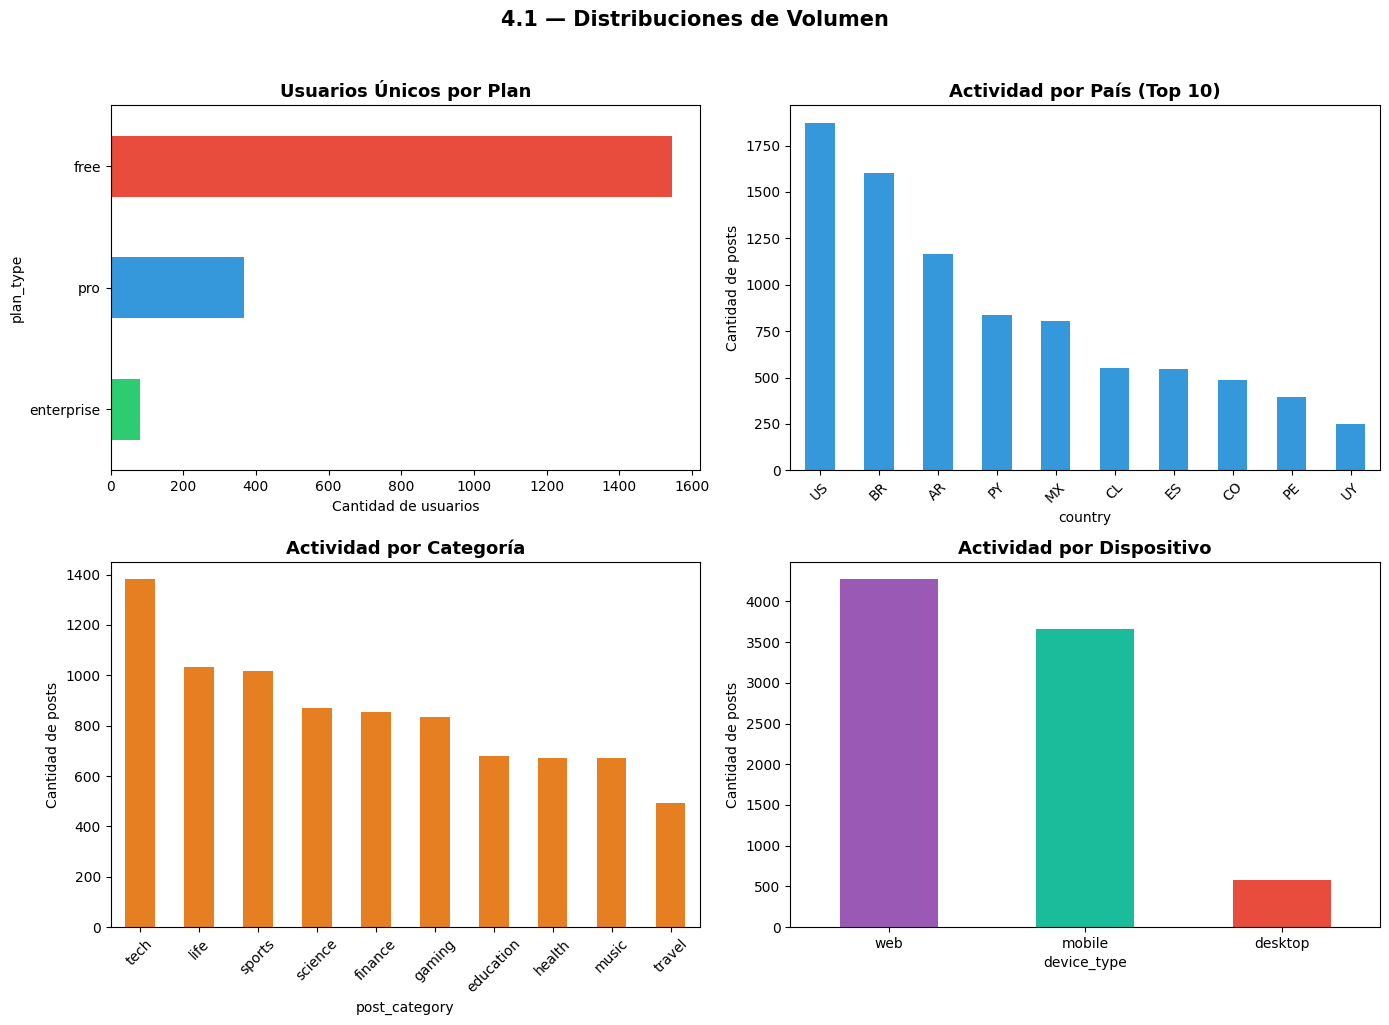

In [11]:
# Usuarios únicos por plan
print("Usuarios únicos por plan:")
users_by_plan = df_clean.groupby("plan_type")["user_id"].nunique()
display(users_by_plan)

# Actividad (#posts) por país, categoría y dispositivo
for col in ["country", "post_category", "device_type"]:
    print(f"\nActividad por {col}:")
    display(df_clean[col].value_counts())

# --- Gráficos de Distribuciones ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Usuarios únicos por plan
users_by_plan.sort_values().plot(
    kind="barh", ax=axes[0, 0], color=["#2ecc71", "#3498db", "#e74c3c"])
axes[0, 0].set_title("Usuarios Únicos por Plan", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Cantidad de usuarios")

# Gráfico 2: Posts por país (top 10)
df_clean["country"].value_counts().head(10).plot(
    kind="bar", ax=axes[0, 1], color="#3498db")
axes[0, 1].set_title("Actividad por País (Top 10)", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Cantidad de posts")
axes[0, 1].tick_params(axis="x", rotation=45)

# Gráfico 3: Posts por categoría
df_clean["post_category"].value_counts().plot(
    kind="bar", ax=axes[1, 0], color="#e67e22")
axes[1, 0].set_title("Actividad por Categoría", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Cantidad de posts")
axes[1, 0].tick_params(axis="x", rotation=45)

# Gráfico 4: Posts por dispositivo
df_clean["device_type"].value_counts().plot(
    kind="bar", ax=axes[1, 1], color=["#9b59b6", "#1abc9c", "#e74c3c"])
axes[1, 1].set_title("Actividad por Dispositivo", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Cantidad de posts")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.suptitle("4.1 — Distribuciones de Volumen", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 — Engagement (Votos)
Media y mediana de votos por plan, país, categoría y dispositivo.


Votos por plan_type:


,mean,median
plan_type,,
enterprise,7.570571,7.0
free,6.692706,6.0
pro,7.654014,7.0



Votos por country:


,mean,median
country,,
AR,6.771404,6.0
BR,6.889375,6.0
CL,7.311594,6.0
CO,7.323770,6.0
ES,6.978022,6.0
MX,6.962594,6.0
PE,6.547074,6.0
PY,6.600956,6.0
US,6.973305,6.0



Votos por post_category:


,mean,median
post_category,,
education,6.791483,6.0
finance,6.978898,6.0
gaming,7.186074,6.0
health,6.456166,6.0
life,6.173114,5.0
music,6.286776,5.0
science,7.544828,6.0
sports,6.573255,6.0
tech,7.687183,7.0



Votos por device_type:


,mean,median
device_type,,
desktop,7.032702,6.0
mobile,6.828228,6.0
web,6.960656,6.0


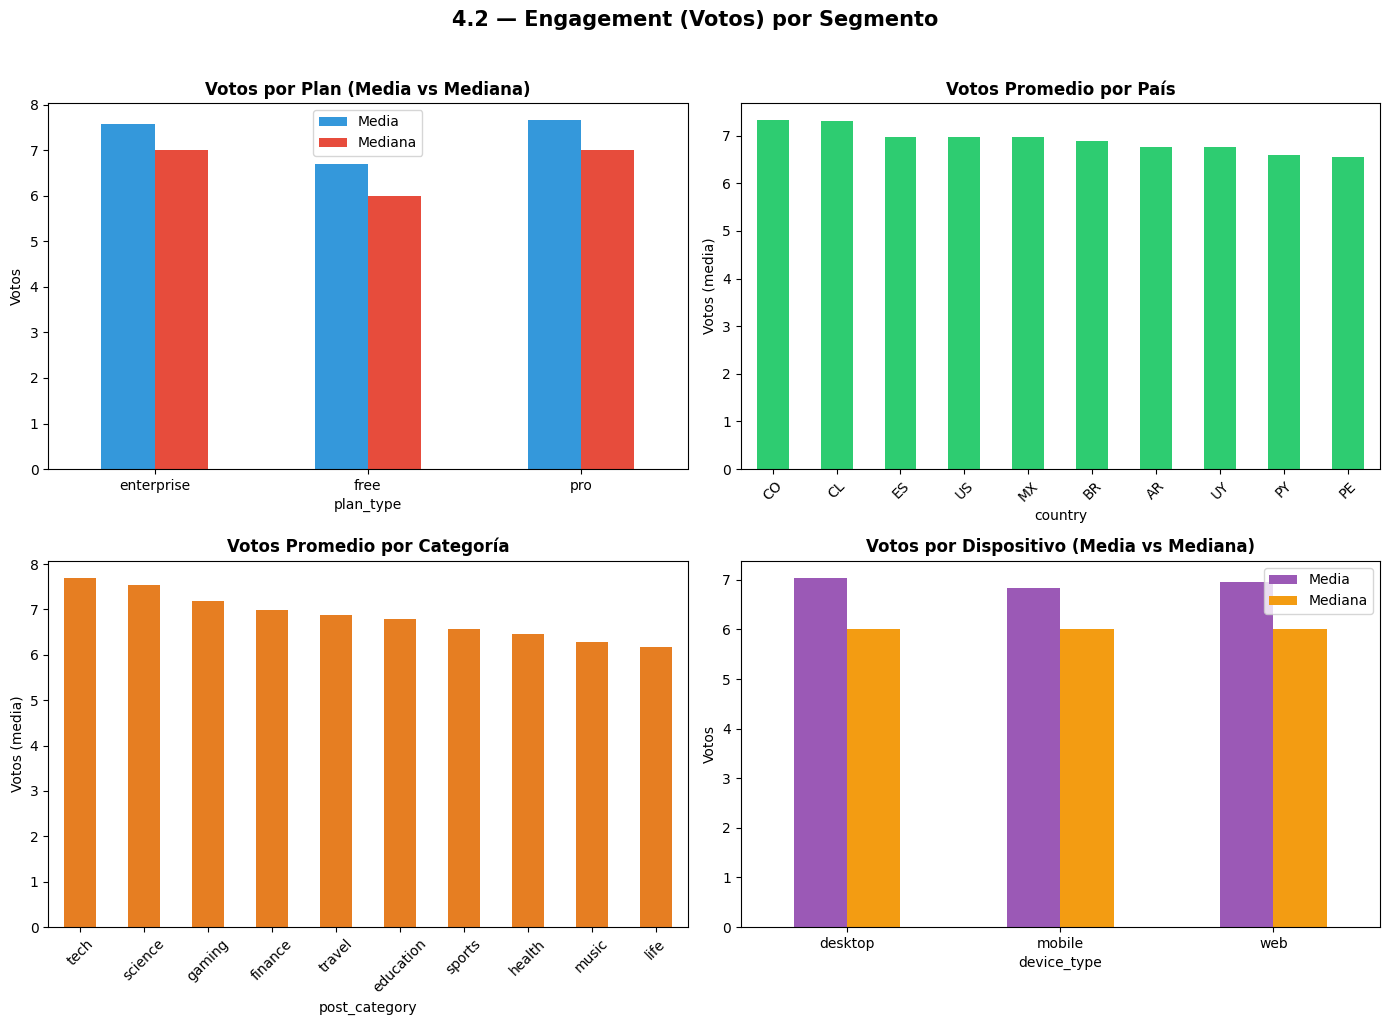

In [12]:
# Votos (media y mediana) segmentados por cada dimensión
for col in ["plan_type", "country", "post_category", "device_type"]:
    print(f"\nVotos por {col}:")
    display(df_clean.groupby(col)["votes_received"].agg(["mean", "median"]))

# --- Gráficos de Engagement ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Engagement por plan
eng_plan = df_clean.groupby("plan_type")["votes_received"].agg(["mean", "median"])
eng_plan.plot(kind="bar", ax=axes[0, 0], color=["#3498db", "#e74c3c"])
axes[0, 0].set_title("Votos por Plan (Media vs Mediana)", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Votos")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].legend(["Media", "Mediana"])

# Engagement por país
eng_country = df_clean.groupby("country")["votes_received"].mean().sort_values(ascending=False)
eng_country.plot(kind="bar", ax=axes[0, 1], color="#2ecc71")
axes[0, 1].set_title("Votos Promedio por País", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Votos (media)")
axes[0, 1].tick_params(axis="x", rotation=45)

# Engagement por categoría
eng_cat = df_clean.groupby("post_category")["votes_received"].mean().sort_values(ascending=False)
eng_cat.plot(kind="bar", ax=axes[1, 0], color="#e67e22")
axes[1, 0].set_title("Votos Promedio por Categoría", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Votos (media)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Engagement por dispositivo
eng_dev = df_clean.groupby("device_type")["votes_received"].agg(["mean", "median"])
eng_dev.plot(kind="bar", ax=axes[1, 1], color=["#9b59b6", "#f39c12"])
axes[1, 1].set_title("Votos por Dispositivo (Media vs Mediana)", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Votos")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(["Media", "Mediana"])

plt.suptitle("4.2 — Engagement (Votos) por Segmento", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 — Promedios e Interpretación

**Interpretación:** La unidad de análisis es el *evento* (cada fila = un post).
Un usuario con muchos posts impacta fuertemente en el promedio general,
ya que sus votos se contabilizan repetidamente.
Esto genera un sesgo hacia los heavy users / outliers.

In [13]:
# Promedio de votos por plan
print("Promedio de votos por plan:")
display(df_clean.groupby("plan_type")["votes_received"].mean())

# Posts promedio por usuario
avg_posts = df_clean.groupby("user_id")["post_id"].count().mean()
print(f"\nPosts promedio por usuario: {avg_posts:.2f}")

Promedio de votos por plan:


plan_type
enterprise    7.570571
free          6.692706
pro           7.654014
Name: votes_received, dtype: float64


Posts promedio por usuario: 4.27


### 4.4 — Evento vs Usuario

**¿Por qué difieren?** A nivel *evento*, los usuarios más activos
sobrerrepresentan la muestra (si un usuario hace 100 posts, su media
pesará 100 veces más). Al calcular por *usuario*, cada persona pesa
igual (1 promedio), eliminando el efecto de los heavy users.

In [14]:
# Promedio de votos a nivel EVENTO (por fila)
avg_event = df_clean["votes_received"].mean()
print(f"Promedio de votos por evento (fila): {avg_event:.4f}")

# Promedio de votos a nivel USUARIO (agrupado)
avg_user = df_clean.groupby("user_id")["votes_received"].mean().mean()
print(f"Promedio de votos por usuario:       {avg_user:.4f}")

Promedio de votos por evento (fila): 6.9087
Promedio de votos por usuario:       6.8967


## 5. Concentración y Temporalidad

### 5.1 — Concentración (Top 1%)
¿Qué porcentaje de posts/votos viene del top 1% de usuarios?

Top 1% usuarios por posts: 24 usuarios
Top 1% → 6.97% de los posts
Top 1% → 6.43% de los votos


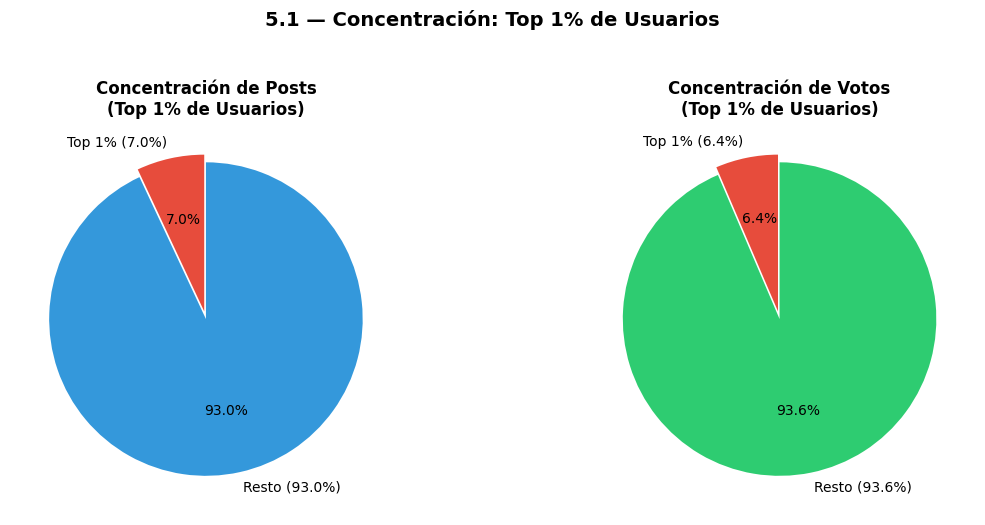

In [15]:
# Posts y votos por usuario
user_posts = df_clean.groupby("user_id")["post_id"].count()
user_votes = df_clean.groupby("user_id")["votes_received"].sum()

# Top 1% de usuarios
top1_posts = user_posts[user_posts >= user_posts.quantile(0.99)]
top1_votes = user_votes[user_votes >= user_votes.quantile(0.99)]

top1_post_pct = top1_posts.sum() / user_posts.sum() * 100
top1_vote_pct = top1_votes.sum() / user_votes.sum() * 100

print(f"Top 1% usuarios por posts: {len(top1_posts)} usuarios")
print(f"Top 1% → {top1_post_pct:.2f}% de los posts")
print(f"Top 1% → {top1_vote_pct:.2f}% de los votos")

# --- Gráfico de concentración ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart: concentración de posts
rest_post_pct = 100 - top1_post_pct
axes[0].pie([top1_post_pct, rest_post_pct],
            labels=[f"Top 1% ({top1_post_pct:.1f}%)", f"Resto ({rest_post_pct:.1f}%)"],
            colors=["#e74c3c", "#3498db"],
            autopct="%1.1f%%", startangle=90,
            explode=[0.05, 0])
axes[0].set_title("Concentración de Posts\n(Top 1% de Usuarios)", fontsize=12, fontweight="bold")

# Pie chart: concentración de votos
rest_vote_pct = 100 - top1_vote_pct
axes[1].pie([top1_vote_pct, rest_vote_pct],
            labels=[f"Top 1% ({top1_vote_pct:.1f}%)", f"Resto ({rest_vote_pct:.1f}%)"],
            colors=["#e74c3c", "#2ecc71"],
            autopct="%1.1f%%", startangle=90,
            explode=[0.05, 0])
axes[1].set_title("Concentración de Votos\n(Top 1% de Usuarios)", fontsize=12, fontweight="bold")

plt.suptitle("5.1 — Concentración: Top 1% de Usuarios", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

### 5.2 — Tendencia temporal
Actividad y engagement por mes.

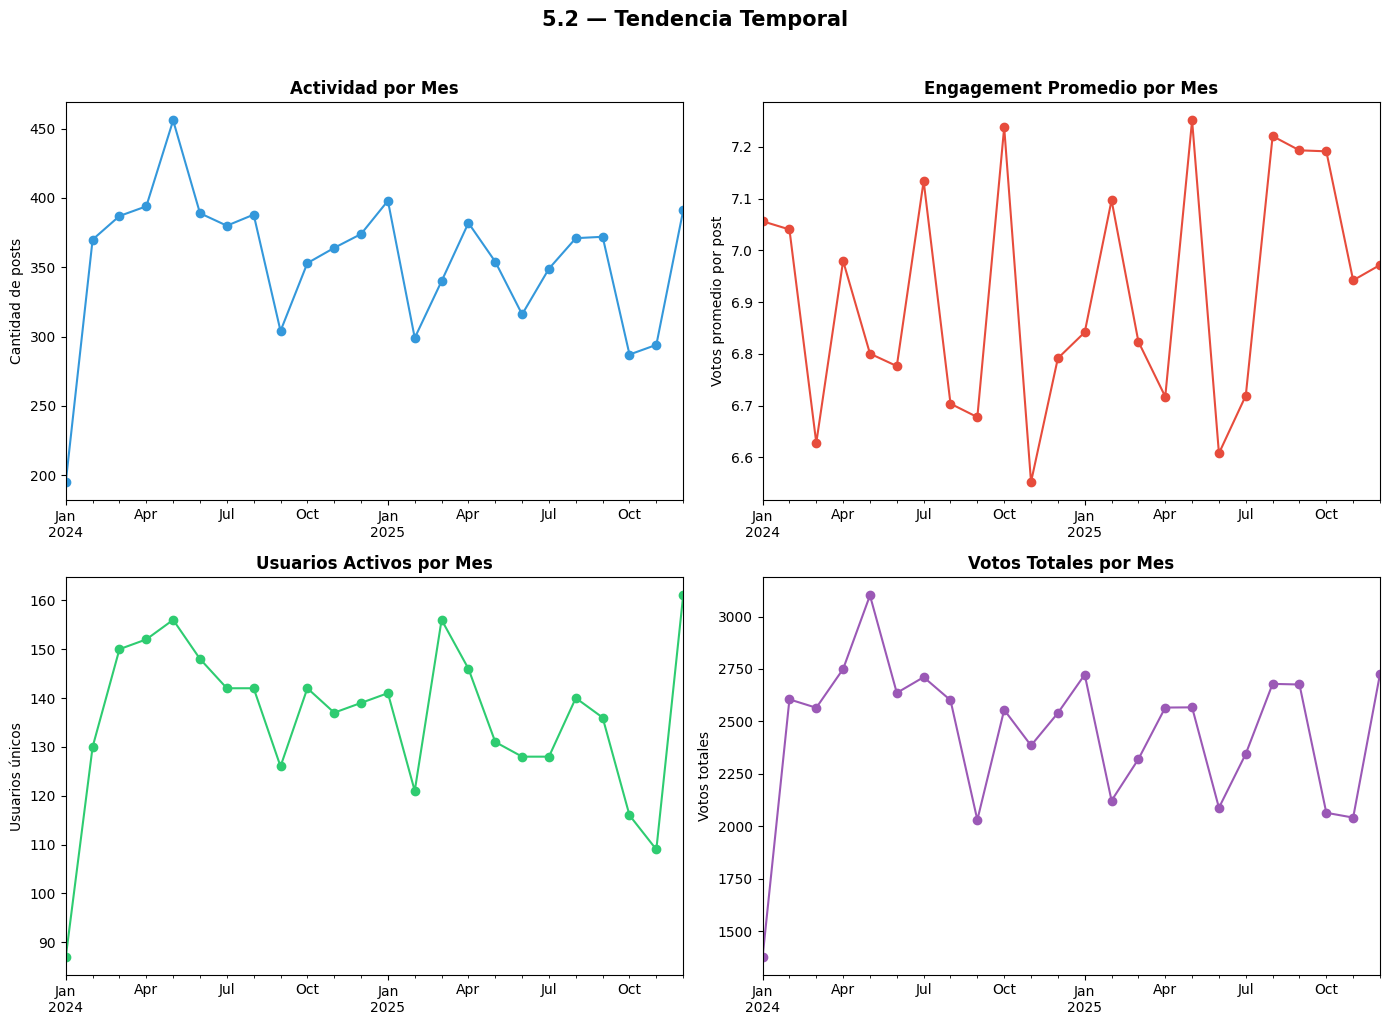

In [16]:
# Agrupar por mes
df_clean["month"] = df_clean["post_created_at"].dt.to_period("M")

monthly = df_clean.groupby("month").agg(
    posts=("post_id", "count"),
    avg_votes=("votes_received", "mean"),
    total_votes=("votes_received", "sum"),
    active_users=("user_id", "nunique")
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actividad (posts) por mes
monthly["posts"].plot(kind="line", ax=axes[0, 0], marker="o", color="#3498db")
axes[0, 0].set_title("Actividad por Mes", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Cantidad de posts")
axes[0, 0].set_xlabel("")

# 2. Engagement promedio por mes
monthly["avg_votes"].plot(kind="line", ax=axes[0, 1], marker="o", color="#e74c3c")
axes[0, 1].set_title("Engagement Promedio por Mes", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Votos promedio por post")
axes[0, 1].set_xlabel("")

# 3. Usuarios activos por mes
monthly["active_users"].plot(kind="line", ax=axes[1, 0], marker="o", color="#2ecc71")
axes[1, 0].set_title("Usuarios Activos por Mes", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Usuarios únicos")
axes[1, 0].set_xlabel("")

# 4. Votos totales por mes
monthly["total_votes"].plot(kind="line", ax=axes[1, 1], marker="o", color="#9b59b6")
axes[1, 1].set_title("Votos Totales por Mes", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Votos totales")
axes[1, 1].set_xlabel("")

plt.suptitle("5.2 — Tendencia Temporal", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Product Decisions (Basadas en evidencia)

### 6.1 — Preguntas

**¿Qué segmento priorizarías y por qué?**

Priorizaría los usuarios **Pro**, porque:
- Tienen el engagement más alto (votos promedio ~7.65 vs ~6.69 de Free) según la sección 4.2.
- Son un grupo de tamaño intermedio (367 usuarios) con potencial de crecimiento.
- Invertir en retenerlos y convertir usuarios Free a Pro genera mayor impacto que enfocarse en Enterprise (solo 82 usuarios).

**¿Qué parte del tablero "mentía" antes de limpiar?**

La columna `days_since_signup`. Según la sección 1.4, el **50.11%** de las filas tenía un valor diferente al recalculado a partir de las fechas reales (`post_created_at - created_at`). Cualquier métrica basada en antigüedad del usuario (retención, LTV, cohortes) era incorrecta.

**¿Qué nuevo dato agregarías al tracking?**

Agregaría `session_duration` (tiempo de sesión del usuario). Actualmente solo medimos votos, pero un usuario puede consumir contenido sin votar. Medir el tiempo permite diferenciar entre un post ignorado y uno leído pero no votado.

### 6.2 — Acciones concretas

**Acción 1 — Reducir la concentración de actividad:**
- *Problema:* El top 1% de usuarios genera ~7% de los posts y ~6.4% de los votos (sección 5.1). La plataforma depende de pocos power users.
- *Acción:* Implementar notificaciones de "tu primer post de la semana" y gamificación (badges) para incentivar publicación en usuarios pasivos.
- *Respaldo:* Gráfico de concentración, sección 5.1.

**Acción 2 — Optimizar la experiencia mobile:**
- *Problema:* Mobile representa ~43% de la actividad total (3,656 de 8,507 posts) pero su engagement promedio es el más bajo (~6.83 votos vs ~7.03 en desktop), según sección 4.1 y 4.2.
- *Acción:* Rediseñar la interfaz de creación de posts en mobile para reducir fricción y mejorar la calidad del contenido publicado desde ese dispositivo.
- *Respaldo:* Gráficos de distribución por dispositivo (4.1) y engagement por dispositivo (4.2).

### Limitaciones del dataset
- No hay datos de retención ni duración de sesión → no se puede medir engagement real.
- `user_total_posts` se repite por fila → sesga promedios si no se agrupa por usuario.
- No hay información sobre calidad del contenido (longitud, multimedia).
- La columna `days_since_signup` original no es confiable; se usa la versión recalculada.

## 7. Exportación de Archivos

In [17]:
# 1. Dataset limpio (core)
df_clean.to_csv("clean_product_activity.csv", index=False)
print("Exportado: clean_product_activity.csv")

# 2. Dataset cuarentena (con motivo de exclusión)
df_quarantine.to_csv("quarantine_product_activity.csv", index=False)
print("Exportado: quarantine_product_activity.csv")

# 3. Tabla resumen de métricas clave
metrics = pd.DataFrame({
    "Métrica": ["unique_users", "total_core_posts",
                "avg_votes_per_event", "avg_votes_per_user",
                "top1_post_pct", "top1_vote_pct"],
    "Valor": [df_clean["user_id"].nunique(), len(df_clean),
              avg_event, avg_user,
              top1_post_pct, top1_vote_pct],
})
metrics.to_csv("metrics_summary.csv", index=False)
print("Exportado: metrics_summary.csv")

print("\nExportación completa.")

Exportado: clean_product_activity.csv
Exportado: quarantine_product_activity.csv
Exportado: metrics_summary.csv

Exportación completa.
